## imports


In [2]:
print(f"hello world")

hello world


In [3]:
import os
import sys
import matplotlib.pyplot as plt
from itertools import chain
import selfeeg
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from torch.utils.data import DataLoader

import warnings
warnings.filterwarnings("ignore", message="Using padding='same'", category=UserWarning)

In [4]:
dir_base = Path("../..")
print(os.path.abspath(dir_base))

sys.path.append(os.path.abspath(dir_base))


c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg


In [5]:
%load_ext autoreload
%autoreload 2

# from shallownetXAI_main.AllFnc.models import ShallowNet, ShallowNet2

from backend.ml.data_utils.load_data import *

from backend.ml.scc_cache import SCCStore, SCCParams, build_x_y_scc, CachedSCCDataset, SCCReducer, pairs_to_dense
from backend.ml.xeegnet_scc_utils.training_utils_xeegnet_scc import *
from backend.ml.xeegnet_scc_utils.model_evaluations import *


c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### paths


In [6]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
dir_data_abs = os.path.abspath(dir_data)
data_path = os.path.join(dir_data, "sub-001", "eeg", "sub-001_task-eyesclosed_eeg.set")

dir_data_outer = os.path.join(dir_base, "data")

dir_shallownetXAI = os.path.join(
    dir_base, "backend", "experiments_xeegnet", "shallownetXAI_main"
)

# data_path = os.path.join(dir_data_abs, 'ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set')

# Read Data


In [7]:
df_metadata = load_metadata(dir_data)

In [8]:
df_metadata.head(2)

,participant_id,Gender,Age,Group,MMSE,group_long,group_encoded,participant_id_int
0,sub-001,F,57,A,16,Alzheimer Disease Group,1,1
1,sub-002,F,78,A,22,Alzheimer Disease Group,1,2


In [9]:
df_results_path = Path(dir_base) / "backend" / "experiments_xeegnet" / "results" / "xeegnet_scc_model_versions_200_204_metrics_alltasks.csv"
df_results = pd.read_csv(df_results_path)

In [10]:
df_results.head(5)

,model_version,model_kind,reducer_mode_scc,model_name,model_path,task,train_epochs,datasplit,aggregation,n_samples,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,recall_weighted,model_kind_reducer
0,200,xeegnet,NaN,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,cn_ad,NaN,test,window,2544,0.730346,0.717627,0.714797,0.719404,0.757302,0.752614,0.717627,0.730346,xeegnet
1,200,xeegnet,NaN,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,cn_ad,NaN,test,subject_majority,12,0.833333,0.833333,0.828571,0.828571,0.875000,0.875000,0.833333,0.833333,xeegnet
2,200,xeegnet,NaN,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,cn_ad,NaN,train,window,8445,0.825104,0.814918,0.818626,0.823655,0.825550,0.825267,0.814918,0.825104,xeegnet
3,200,xeegnet,NaN,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,cn_ad,NaN,train,subject_majority,41,0.902439,0.899510,0.899510,0.902439,0.899510,0.902439,0.899510,0.902439,xeegnet
4,200,xeegnet,NaN,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,cn_ad,NaN,val,window,2293,0.663323,0.667533,0.663276,0.662995,0.668193,0.671851,0.667533,0.663323,xeegnet


In [11]:
df_result_window = filter_results_dataframe(df_results, aggregation="window")

In [12]:
filter_results_dataframe(df_result_window, datasplit="test").groupby(["task", "datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["accuracy"].mean()

task         datasplit  model_kind   reducer_mode_scc
cn_ad        test       xeegnet      NaN                 0.584664
                        xeegnet_scc  edge                0.698586
                                     mean                0.732752
                                     node                0.713295
cn_disease   test       xeegnet      NaN                 0.656773
                        xeegnet_scc  edge                0.702205
                                     mean                0.666386
                                     node                0.717845
cn_ftd       test       xeegnet      NaN                 0.558657
                        xeegnet_scc  edge                0.649904
                                     mean                0.583631
                                     node                0.633381
three_class  test       xeegnet      NaN                 0.488374
                        xeegnet_scc  edge                0.488655
                      

In [13]:
filter_results_dataframe(df_result_window, datasplit="test").groupby(["task", "datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["f1_macro"].mean()

task         datasplit  model_kind   reducer_mode_scc
cn_ad        test       xeegnet      NaN                 0.577908
                        xeegnet_scc  edge                0.696805
                                     mean                0.732124
                                     node                0.712180
cn_disease   test       xeegnet      NaN                 0.591597
                        xeegnet_scc  edge                0.659162
                                     mean                0.629484
                                     node                0.686786
cn_ftd       test       xeegnet      NaN                 0.534823
                        xeegnet_scc  edge                0.638965
                                     mean                0.568545
                                     node                0.624070
three_class  test       xeegnet      NaN                 0.435662
                        xeegnet_scc  edge                0.480607
                      

In [14]:
filter_results_dataframe(df_result_window, datasplit="test").groupby(["model_kind", "reducer_mode_scc"], dropna=False)["accuracy"].mean()

model_kind   reducer_mode_scc
xeegnet      NaN                 0.572117
xeegnet_scc  edge                0.634837
             mean                0.628151
             node                0.640793
Name: accuracy, dtype: float64

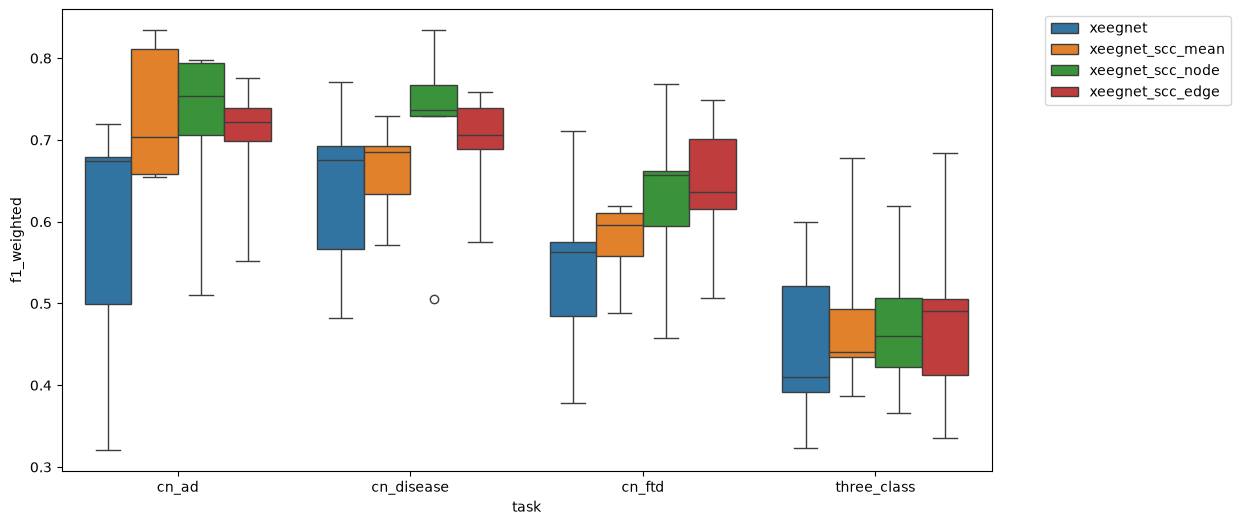

In [22]:
# set figure size
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=filter_results_dataframe(df_results, datasplit="test", aggregation="window"),
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    x="task",
    whis=5.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [23]:
filter_results_dataframe(df_results, datasplit="test", aggregation="subject_majority").groupby(["task", "datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["f1_macro"].mean()
filter_results_dataframe(df_results, datasplit="test", aggregation="subject_majority").groupby(["datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["f1_macro"].mean()

datasplit  model_kind   reducer_mode_scc
test       xeegnet      NaN                 0.548510
           xeegnet_scc  edge                0.666873
                        mean                0.654037
                        node                0.672028
Name: f1_macro, dtype: float64

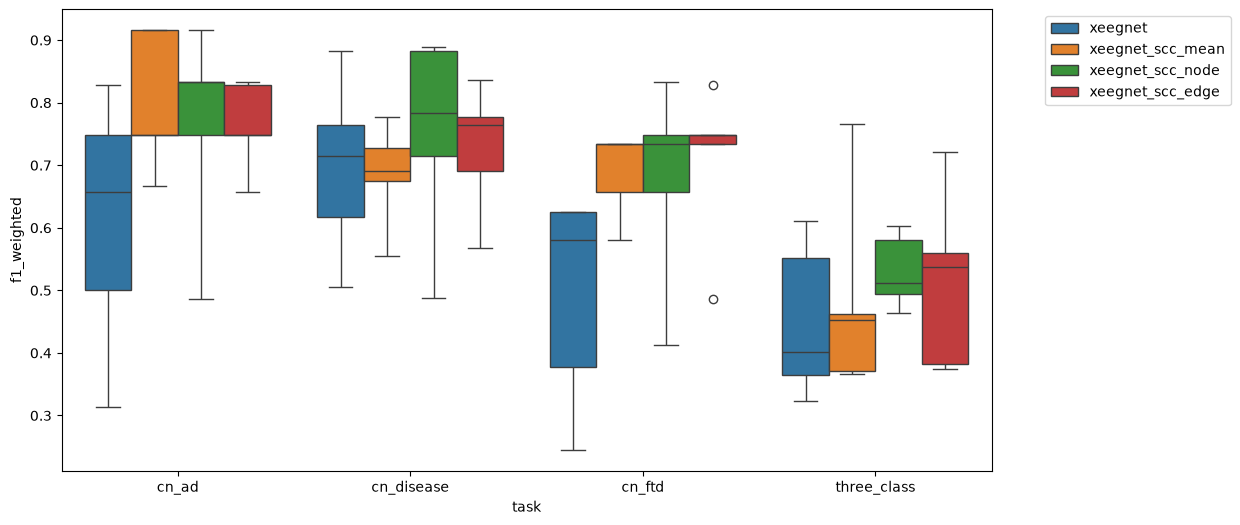

In [17]:
# set figure size
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=filter_results_dataframe(df_results, datasplit="test", aggregation="subject_majority"),
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    x="task",
    whis=5.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

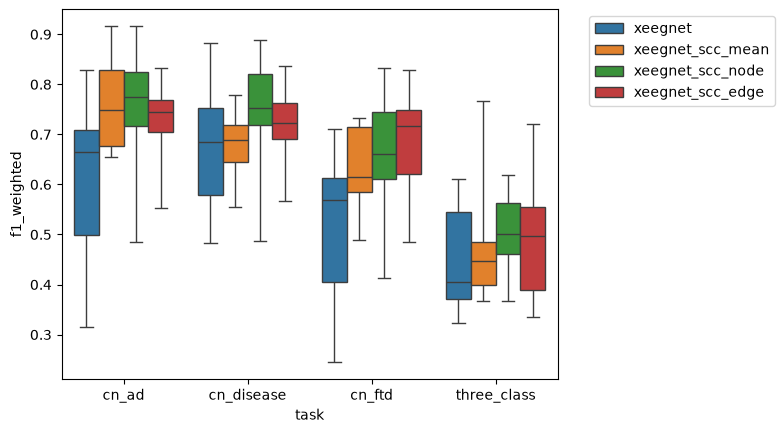

In [21]:
sns.boxplot(
    data=filter_results_dataframe(df_results, datasplit="test"),
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    x="task",
    whis=5.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

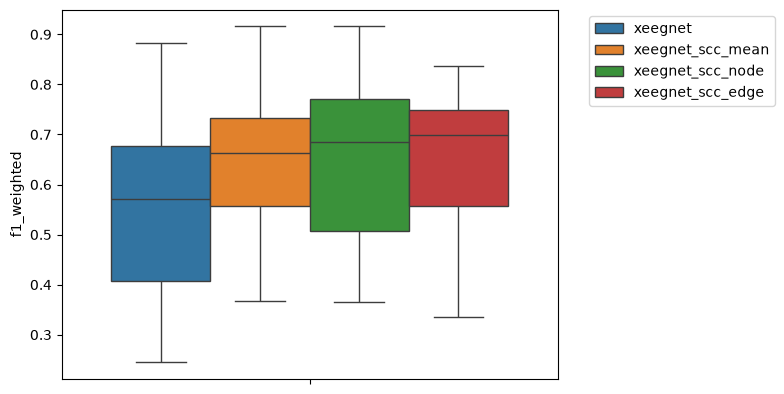

In [22]:


# create a boxplot of the f1_weighted scores for each model_kind and reducer_mode_scc, for the test datasplit
import seaborn as sns 

sns.boxplot(
    data=df_results[df_results["datasplit"] == "test"],
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    whis=4.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

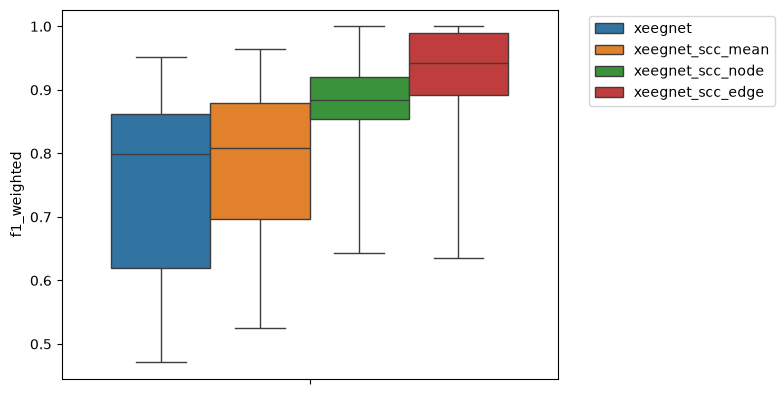

In [23]:
sns.boxplot(
    data=df_results[df_results["datasplit"] == "train"],
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    whis=4.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')